# eda para precificação de veículos usados

objetivo deste notebook:
- entender o dataset de carros usados
- avaliar qualidade e consistência dos dados
- gerar hipóteses para modelagem com regressão regularizada (ridge/lasso)

## roteiro da análise

1. carregamento e identificação da target  
2. qualidade dos dados  
3. parsing e engenharia de variáveis  
4. análise univariada  
5. análise bivariada com target

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

PASTEL_CYCLE = [
    "#A8DADC",  # azul pastel
    "#FFCAD4",  # rosa pastel
    "#CDEAC0",  # verde pastel
    "#C7CEEA",  # lilas pastel
    "#FFD6A5",  # pessego pastel
    "#BDE0FE",  # azul claro
    "#E4C1F9",  # roxo claro
    "#F1C0E8",  # rosa lavanda
]

sns.set_theme(style="whitegrid")
sns.set_palette(PASTEL_CYCLE)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_CYCLE)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
DATA_DIR = Path("../data")

preferred_files = [
    "train-data.csv",
    "train.csv",
    "used_cars_data.csv",
    "car_price.csv",
    "test-data.csv",
]

available_files = [f for f in preferred_files if (DATA_DIR / f).exists()]
if not available_files:
    raise FileNotFoundError(f"nenhum csv encontrado em {DATA_DIR.resolve()}")

selected_file = DATA_DIR / available_files[0]
df_raw = pd.read_csv(selected_file).copy()

df_raw.columns = [c.strip() for c in df_raw.columns]
unnamed_cols = [c for c in df_raw.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    df_raw = df_raw.drop(columns=unnamed_cols)

target_candidates = ["Price", "price", "Selling_Price", "selling_price", "Sale_Price", "target"]
target_col = next((c for c in target_candidates if c in df_raw.columns), None)

print(f"arquivo selecionado: {selected_file.name}")
print(f"shape: {df_raw.shape}")
print(f"target identificada: {target_col if target_col else 'não encontrada neste arquivo'}")

arquivo selecionado: train-data.csv
shape: (6019, 13)
target identificada: Price


In [3]:
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype"))

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0000,NaN,1.7500
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0000,NaN,12.5000
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0000,8.61 Lakh,4.5000
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0000,NaN,6.0000
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0000,NaN,17.7400


,dtype
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,object
Engine,object
Power,object


- `Price` está numérico (`float64`) e entra como target
- existe mistura de tipos, sendo várias colunas técnicas que estão como `object` (`Mileage`, `Engine`, `Power`, `New_Price`) porque os valores vêm com texto/unidade (`kmpl`, `CC`, `bhp`, `Lakh`)
- isso indica uma etapa obrigatória de parsing antes da modelagem (extrair número e padronizar formato)
- `Name`, `Location`, `Fuel_Type`, `Transmission` e `Owner_Type` são categóricas, vão precisar de one-hot encoding
- `Name` tem tendência de alta cardinalidade. faz sentido derivar `Brand` para reduzir complexidade
- `Seats` apareceu como `float64`, possivelmente por nulos. após tratamento pode virar inteiro
- no `head` já aparecem faltantes em `New_Price`, então vale medir missing_pct para decidir imputação/uso no modelo

dicionário das variáveis
- `Name`: nome completo do carro (marca + modelo + versão)
    - categórica (alta cardinalidade). derivar `Brand` e, se necessário, `Model_short`
- `Location`: cidade onde o carro está sendo vendido
    - categórica
- `Year`: ano do carro
    - numérica (ou transformar em `Age`)
- `Kilometers_Driven`: quilometragem rodada (km)
    - numérica
- `Fuel_Type`: tipo de combustível (Petrol, Diesel, CNG, etc)
    - categórica
- `Transmission`: tipo de câmbio (Manual ou Automatic)
    - categórica
- `Owner_Type`: tipo/ordem de proprietário anterior (First, Second, Third, etc)
    - categórica ordinal (pode tratar como categórica no baseline)
- `Mileage`: consumo/eficiência do carro (vem com unidade em texto, ex: kmpl ou km/kg)
    - numérica após parsing
- `Engine`: cilindrada do motor (em CC, também vem como texto)
    - numérica após parsing
- `Power`: potência do motor (em bhp, também vem como texto)
    - numérica após parsing
- `Seats`: número de assentos
    - numérica discreta
- `New_Price`: preço quando o carro era novo (geralmente em texto com Lakh/Cr)
    - numérica após parsing
- `Price`: preço atual de revenda (target do modelo)
    - numérica contínua (target)

## 2) qualidade dos dados

aqui eu avalio faltantes, duplicatas e consistência básica de faixas.


In [4]:
quality_report = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "missing": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(dropna=False)
}).sort_values(by="missing", ascending=False)

duplicates = df_raw.duplicated().sum()

display(quality_report)
print(f"duplicatas exatas: {duplicates}")

,dtype,missing,missing_pct,unique_values
New_Price,object,5195,86.3100,541
Seats,float64,42,0.7000,10
Engine,object,36,0.6000,147
Power,object,36,0.6000,373
Mileage,object,2,0.0300,443
Name,object,0,0.0000,1876
Location,object,0,0.0000,11
Year,int64,0,0.0000,22
Kilometers_Driven,int64,0,0.0000,3093
Fuel_Type,object,0,0.0000,5


duplicatas exatas: 0


- dataset sem duplicatas
- `Price` (target) está completo, o que é ótimo para treino supervisionado sem perda de amostras por nulo na variável resposta
- `New_Price` tem missing muito alto (`86.31%`). coluna pode atrapalhar mais do que ajudar no baseline
- decisão prática: testar 2 cenários (com e sem `New_Price`) ou já excluir no baseline de ridge/lasso
- `Mileage`, `Engine` e `Power` ainda estão como `object` e com poucos nulos (`0.03%` a `0.60%`), então o principal aqui é parsing de unidade + conversão numérica
- `Seats` tem poucos faltantes (`0.70%`) e depois da imputação pode voltar para inteiro
- `Name` tem alta cardinalidade (`1876` valores únicos), então usar direto no one-hot pode inflar muito a dimensão e aumentar risco de overfitting
- derivar `Brand` de `Name` para reduzir cardinalidade e melhorar estabilidade do modelo regularizado

## 3) parsing e engenharia de variáveis

neste dataset algumas colunas numéricas vêm como texto (ex: `18.9 kmpl`, `1197 CC`, `82 bhp`, `7.5 Lakh`).

a ideia é converter isso para números para poder analisar/modelar.


In [5]:
import re

CURRENT_YEAR = pd.Timestamp.today().year

def parse_numeric_from_text(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace(",", ".")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group()) if m else np.nan

def parse_mileage_value_unit(s):
    if pd.isna(s):
        return (np.nan, np.nan)
    s_low = str(s).strip().lower().replace(",", ".")
    val = parse_numeric_from_text(s_low)

    if "km/kg" in s_low:
        unit = "kmkg"
    elif "kmpl" in s_low:
        unit = "kmpl"
    else:
        unit = np.nan

    return (val, unit)

def parse_new_price_lakh(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    num = parse_numeric_from_text(s)
    if pd.isna(num):
        return np.nan

    s_low = s.lower()
    if "cr" in s_low:
        return num * 100.0
    if "lakh" in s_low:
        return num
    return num

df = df_raw.copy()

if "Mileage" in df.columns:
    mil = df["Mileage"].apply(parse_mileage_value_unit)
    df["Mileage_num"] = mil.str[0]
    df["Mileage_unit"] = mil.str[1]
    df["Mileage_is_kmkg"] = (df["Mileage_unit"] == "kmkg").astype("Int64")
if "Engine" in df.columns:
    df["Engine_num"] = df["Engine"].apply(parse_numeric_from_text)
if "Power" in df.columns:
    df["Power_num"] = df["Power"].apply(parse_numeric_from_text)
if "New_Price" in df.columns:
    df["New_Price_lakh"] = df["New_Price"].apply(parse_new_price_lakh)
if "Year" in df.columns:
    df["Age"] = (CURRENT_YEAR - df["Year"]).clip(lower=0)
if "Name" in df.columns:
    df["Brand"] = df["Name"].astype(str).str.split().str[0]
    df["Model_short"] = df["Name"].astype(str).str.split().str[:2].str.join(" ")

    min_freq = 20
    vc = df["Model_short"].value_counts(dropna=False)
    keep = vc[vc >= min_freq].index
    df["Model_short_capped"] = df["Model_short"].where(df["Model_short"].isin(keep), "Other")

parsed_cols = [
    c for c in [
        "Mileage_num",
        "Mileage_unit",
        "Mileage_is_kmkg",
        "Engine_num",
        "Power_num",
        "New_Price_lakh",
        "Age",
        "Brand",
        "Model_short",
        "Model_short_capped",
    ] if c in df.columns
]
display(df[parsed_cols].head())

,Mileage_num,Mileage_unit,Mileage_is_kmkg,Engine_num,Power_num,New_Price_lakh,Age,Brand,Model_short,Model_short_capped
0,26.6000,kmkg,1,998.0000,58.1600,NaN,16,Maruti,Maruti Wagon,Maruti Wagon
1,19.6700,kmpl,0,"1,582.0000",126.2000,NaN,11,Hyundai,Hyundai Creta,Hyundai Creta
2,18.2000,kmpl,0,"1,199.0000",88.7000,8.6100,15,Honda,Honda Jazz,Honda Jazz
3,20.7700,kmpl,0,"1,248.0000",88.7600,NaN,14,Maruti,Maruti Ertiga,Maruti Ertiga
4,15.2000,kmpl,0,"1,968.0000",140.8000,NaN,13,Audi,Audi A4,Audi A4


- neste passo eu deixei o parsing mais robusto para texto numérico (incluindo vírgula decimal) o que reduz erro silencioso de conversão
- em `Mileage`, agora separo **valor** (`Mileage_num`) e **unidade** (`Mileage_unit`), evitando misturar `kmpl` com `km/kg` como se fossem a mesma medida
- a flag `Mileage_is_kmkg` facilita uso no modelo sem perder informação de unidade
- `New_Price_lakh` continua padronizada em lakh (`Cr` -> `*100`), então a escala de preço novo fica consistente
- `Age` ficou dinâmica com o ano atual (sem hardcode) e com `clip(lower=0)` para proteger contra anos anômalos
- `Brand` e `Model_short` continuam como engenharia de texto de `Name`, e `Model_short_capped` reduz categorias raras para `"Other"`

### implicações para modelagem

- `Model_short_capped` reduz dimensionalidade do one-hot e tende a melhorar estabilidade de ridge/lasso
- `Mileage_unit` e `Mileage_is_kmkg` carregam informação semelhante. no baseline, usar só uma delas já é suficiente
- manter colunas originais + derivadas é útil para auditoria de parsing e comparação de performance entre versões
- próximo passo é validar missing/outliers das colunas novas antes do pipeline final

In [7]:
num_cols_candidates = ["Year", "Age", "Kilometers_Driven", "Mileage_num", "Engine_num", "Power_num", "Seats", "New_Price_lakh"]
num_cols = [c for c in num_cols_candidates if c in df.columns]

cat_cols_candidates = ["Brand", "Fuel_Type", "Transmission", "Owner_Type", "Location"]
cat_cols = [c for c in cat_cols_candidates if c in df.columns]

print("colunas numéricas para análise:", num_cols)
print("colunas categóricas para análise:", cat_cols)

display(df[num_cols].describe().T)

colunas numéricas para análise: ['Year', 'Age', 'Kilometers_Driven', 'Mileage_num', 'Engine_num', 'Power_num', 'Seats', 'New_Price_lakh']
colunas categóricas para análise: ['Brand', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Location']


,count,mean,std,min,25%,50%,75%,max
Year,"6,019.0000","2,013.3582",3.2697,"1,998.0000","2,011.0000","2,014.0000","2,016.0000","2,019.0000"
Age,"6,019.0000",12.6418,3.2697,7.0000,10.0000,12.0000,15.0000,28.0000
Kilometers_Driven,"6,019.0000","58,738.3803","91,268.8432",171.0000,"34,000.0000","53,000.0000","73,000.0000","6,500,000.0000"
Mileage_num,"6,017.0000",18.1350,4.5823,0.0000,15.1700,18.1500,21.1000,33.5400
Engine_num,"5,983.0000","1,621.2764",601.3552,72.0000,"1,198.0000","1,493.0000","1,984.0000","5,998.0000"
Power_num,"5,876.0000",113.2530,53.8750,34.2000,75.0000,97.7000,138.1000,560.0000
Seats,"5,977.0000",5.2787,0.8088,0.0000,5.0000,5.0000,5.0000,10.0000
New_Price_lakh,824.0000,23.0757,26.1824,3.9100,7.9775,11.6700,26.5600,230.0000


- neste passo eu separei as variáveis por tipo para preparar análises e modelagem de forma organizada

- `Year` e `Age` contam a mesma história (uma é derivada da outra)
  para o modelo, faz sentido manter só `Age`

- perfil geral dos carros tem concentração entre `2011` e `2016` (idade típica entre `10` e `15` anos)

- `Kilometers_Driven` tem mediana de `53.000`, mas máximo de `6.500.000` 
  existe valor muito fora do padrão e isso pode distorcer média e treino

- `Mileage_num` está com distribuição plausível (mediana ~`18.15`), mas tem valor `0`, que pode ser erro de cadastro

- `Engine_num` e `Power_num` têm alguns faltantes, mas em volume administrável para imputação simples (ex: mediana)

- `Seats` está super concentrada em `5` lugares (bom sinal de consistência), porém `min=0` sugere registro inválido

- `New_Price_lakh` tem só `824` valores preenchidos (~`13,7%` da base), então é uma feature com baixa cobertura
  testar modelo com e sem essa coluna

- colunas categóricas (`Brand`, `Fuel_Type`, `Transmission`, `Owner_Type`, `Location`) definidas para one-hot

## 4) análise univariada

aqui eu avalio distribuição e concentração das variáveis.


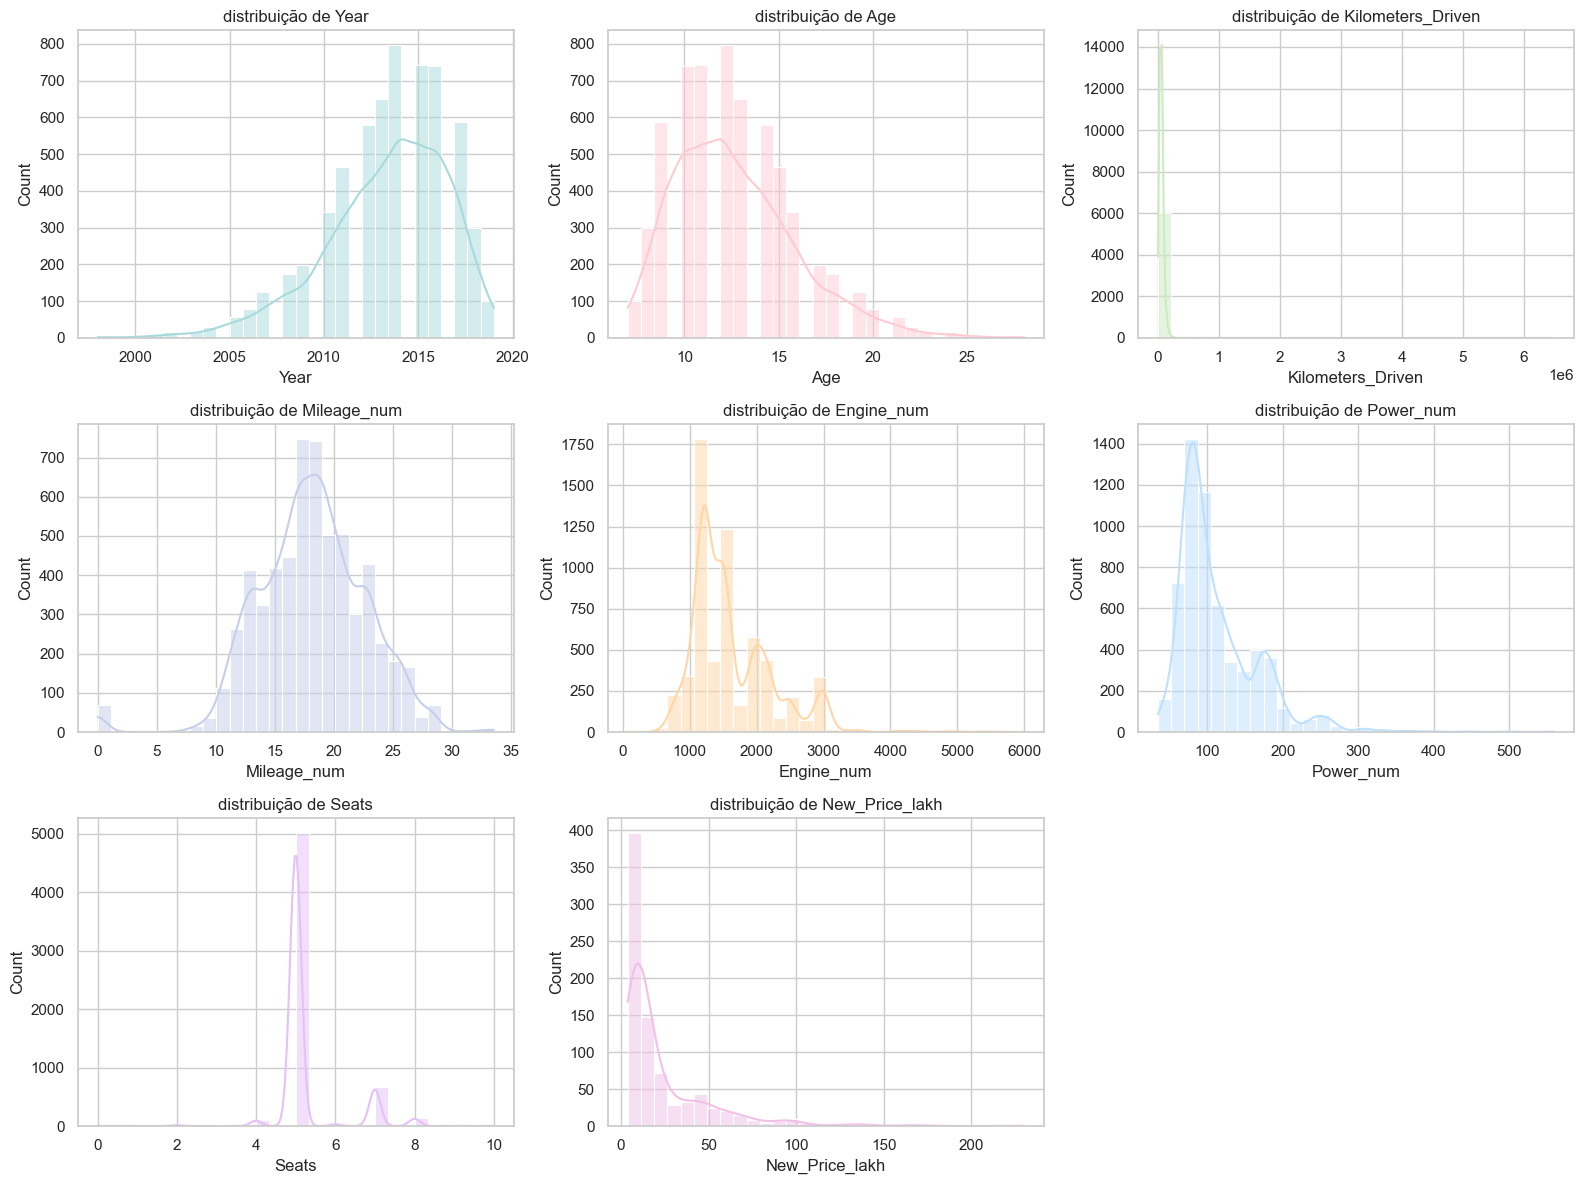

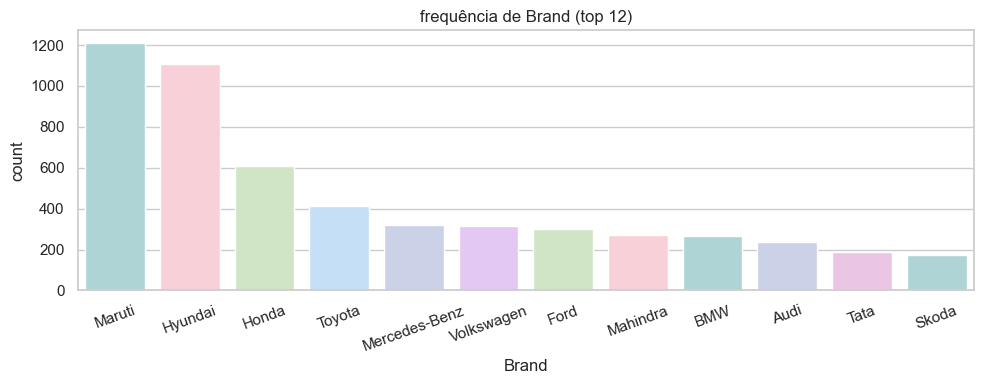

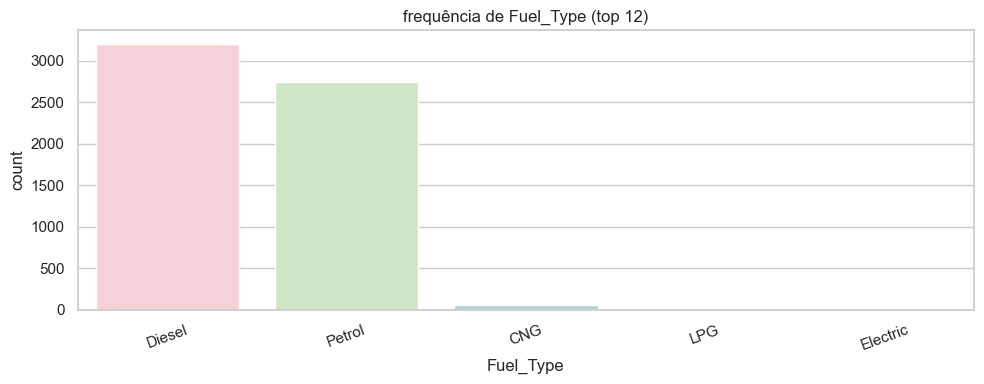

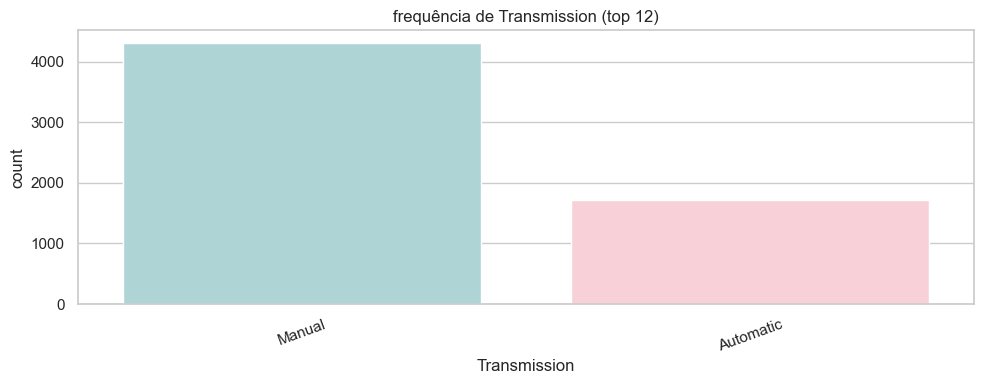

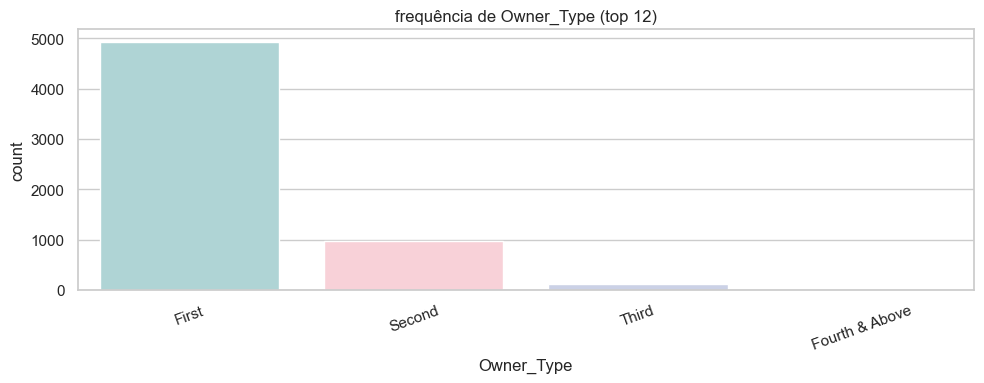

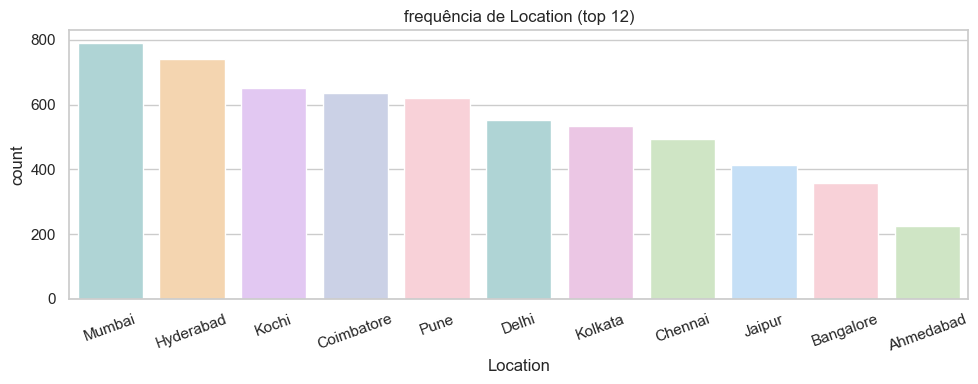

In [8]:
if num_cols:
    n = len(num_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(num_cols):
        color = PASTEL_CYCLE[i % len(PASTEL_CYCLE)]
        sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color=color, edgecolor="white")
        axes[i].set_title(f"distribuição de {col}")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts(dropna=False).head(12).index
    palette = sns.color_palette(PASTEL_CYCLE, n_colors=len(order))
    sns.countplot(data=df, x=col, order=order, hue=col, palette=palette, legend=False)
    plt.title(f"frequência de {col} (top 12)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

- `year` e `age` contam a mesma história (um é o espelho do outro). para modelagem, faz mais sentido manter só `age`
- a base está concentrada em carros mais novos (pico por volta de 2012–2016), com cauda pequena de carros muito antigos
- `kilometers_driven` está bem assimétrica, com poucos valores extremamente altos (outliers), o que pode puxar média e erro do modelo
- `mileage_num` ficou em faixa plausível na maior parte dos casos, mas existem valores `0` que parecem inconsistentes
- `engine_num` e `power_num` têm concentração em faixas específicas (segmentos de mercado) e cauda à direita
- `seats` está muito concentrada em `5`, com alguns `7`; valores `0` sugerem dado inválido
- `new_price_lakh` tem distribuição bem concentrada em valores baixos e cauda longa. além disso, a cobertura dessa coluna é baixa

- `brand` é desbalanceada (maruti/hyundai/honda aparecem bem mais que as demais)
- `fuel_type` é quase todo `diesel`/`petrol`. `cng/lpg/electric` são raros
- `transmission` tem maioria `manual`
- `owner_type` tem forte concentração em `first`, com poucas observações nas classes mais altas
- `location` é relativamente distribuída entre cidades, sem uma única cidade dominando de forma extrema


- usar `age` no lugar de `year`
- tratar outliers (principalmente em `kilometers_driven`, `power_num` e `new_price_lakh`)
- revisar valores possivelmente inválidos (`seats=0`, `mileage_num=0`)
- agrupar categorias raras em `fuel_type`/`owner_type` (e manter controle de cardinalidade em `brand`)

## 5) análise com target

target usada: Price


,target_stats
count,"6,019.0000"
mean,9.4795
std,11.1879
min,0.4400
25%,3.5000
50%,5.6400
75%,9.9500
max,160.0000


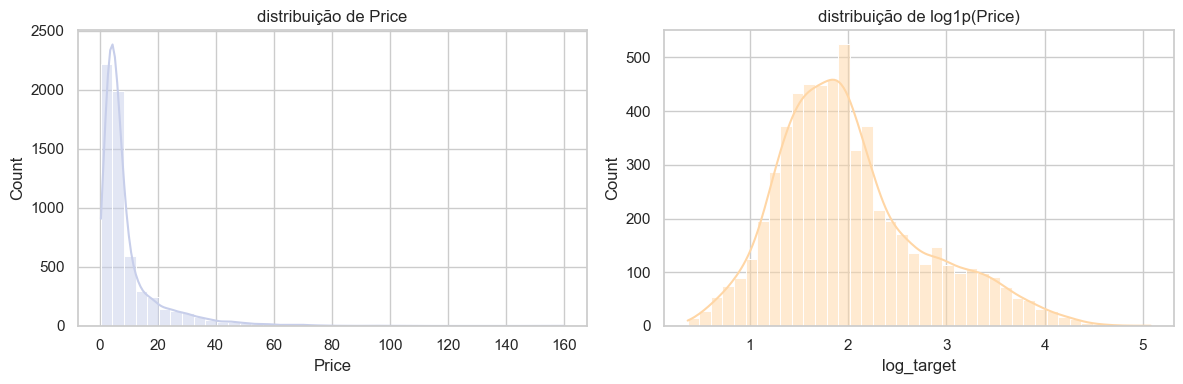

,feature,pearson_r,p_pearson,spearman_rho,p_spearman
7,New_Price_lakh,0.8718,0.0000,0.8865,0.0000
5,Power_num,0.7726,0.0000,0.7597,0.0000
4,Engine_num,0.6584,0.0000,0.6773,0.0000
0,Year,0.3053,0.0000,0.4905,0.0000
6,Seats,0.0522,0.0001,0.2212,0.0000
2,Kilometers_Driven,-0.0115,0.3727,-0.2152,0.0000
3,Mileage_num,-0.3066,0.0000,-0.2794,0.0000
1,Age,-0.3053,0.0000,-0.4905,0.0000


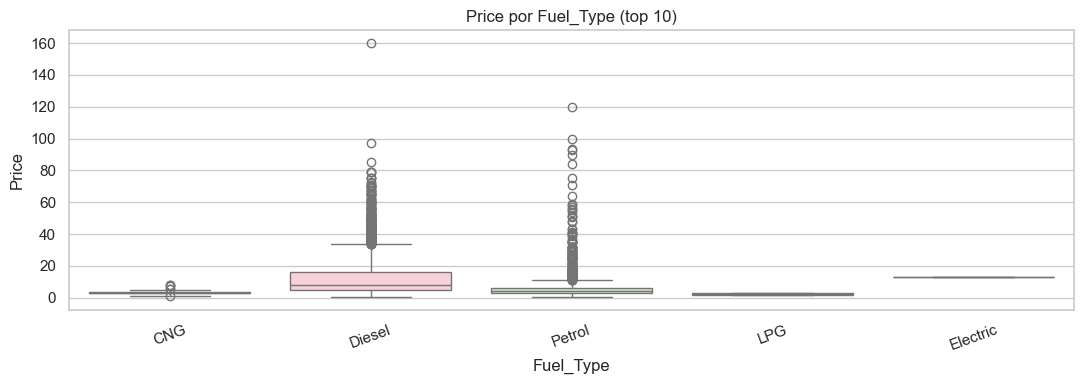

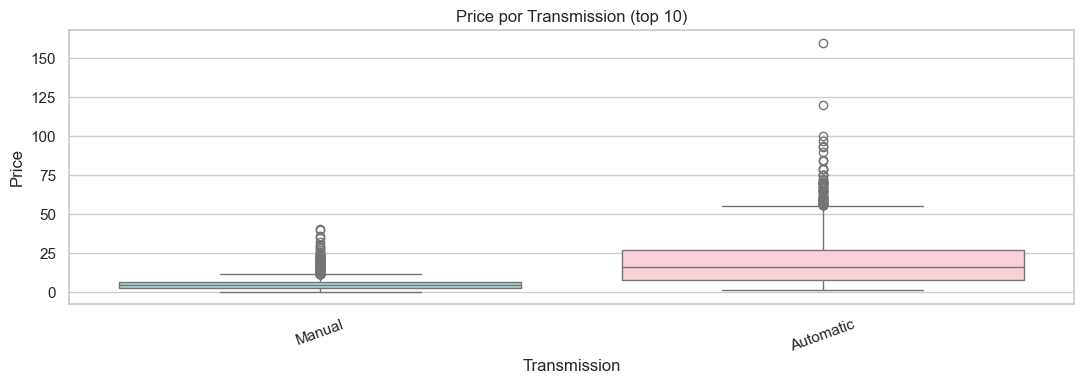

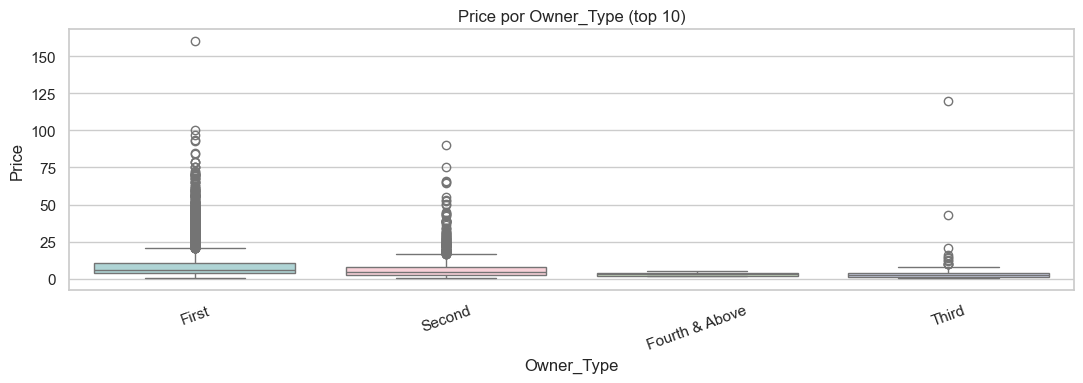

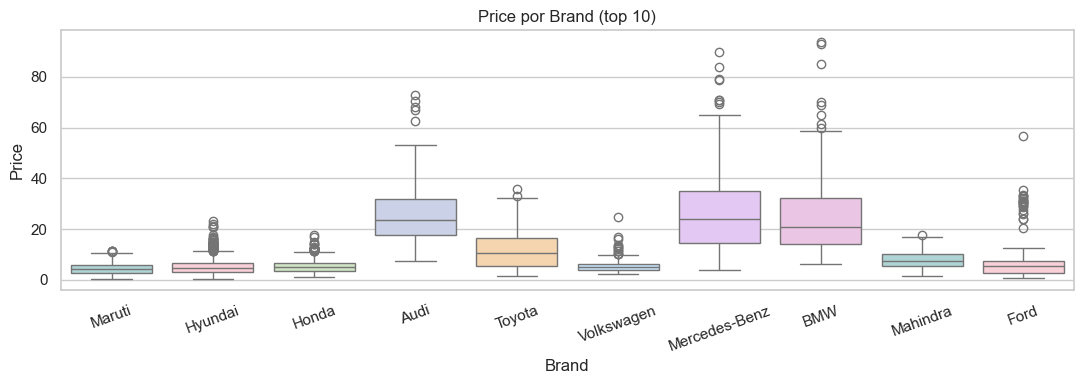

In [9]:
if target_col is None:
    print("este arquivo não tem target de preço. para modelagem supervisionada, adicione um arquivo de treino com coluna de preço (ex: Price).")
else:
    print(f"target usada: {target_col}")
    display(df[target_col].describe().to_frame("target_stats"))

    y = df[target_col].copy()
    if (y <= 0).sum() == 0:
        df["log_target"] = np.log1p(y)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(y, bins=40, kde=True, ax=axes[0], color=PASTEL_CYCLE[3], edgecolor="white")
        axes[0].set_title(f"distribuição de {target_col}")
        sns.histplot(df["log_target"], bins=40, kde=True, ax=axes[1], color=PASTEL_CYCLE[4], edgecolor="white")
        axes[1].set_title(f"distribuição de log1p({target_col})")
        plt.tight_layout()
        plt.show()

    corr_rows = []
    for col in num_cols:
        tmp = df[[col, target_col]].dropna()
        if tmp.shape[0] < 3:
            continue
        r_p, p_p = stats.pearsonr(tmp[col], tmp[target_col])
        r_s, p_s = stats.spearmanr(tmp[col], tmp[target_col])
        corr_rows.append({"feature": col, "pearson_r": r_p, "p_pearson": p_p, "spearman_rho": r_s, "p_spearman": p_s})
    corr_table = pd.DataFrame(corr_rows).sort_values("spearman_rho", ascending=False)
    display(corr_table.round(4))

    for col in [c for c in ["Fuel_Type", "Transmission", "Owner_Type", "Brand"] if c in df.columns]:
        plt.figure(figsize=(11, 4))
        order = df[col].value_counts().head(10).index
        palette = sns.color_palette(PASTEL_CYCLE, n_colors=len(order))
        sns.boxplot(data=df[df[col].isin(order)], x=col, y=target_col, hue=col, palette=palette, legend=False)
        plt.title(f"{target_col} por {col} (top 10)")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

- a target `Price` está disponível com `6019` registros, então a análise supervisionada foi executada normalmente
- a distribuição de `Price` é bem assimétrica à direita, maioria dos carros em faixas mais baixas e poucos muito caros (média `9.48` > mediana `5.64`, máximo `160`)
- o `log1p(Price)` deixa a distribuição mais “comportada”, o que tende a ajudar modelos lineares (ridge/lasso)

- correlações mais fortes com preço
  - `New_Price_lakh` (forte positiva)
  - `Power_num` (forte positiva)
  - `Engine_num` (moderada/forte positiva)
- `Year` tem correlação positiva e `Age` negativa (esperado, porque são espelhos)
- `Mileage_num` aparece com correlação negativa moderada
- `Kilometers_Driven` quase não mostra relação linear (pearson fraco), mas mostra tendência negativa no spearman
- `Seats` tem sinal fraco para preço

- boxplots:
  - `Automatic` tende a preços maiores que `Manual`
  - marcas premium (`Mercedes-Benz`, `BMW`, `Audi`) concentram preços mais altos
  - `First owner` tende a faixa de preço maior que `Second/Third`
  - há muitos outliers em várias categorias, principalmente nas faixas altas de preço

- categorias com poucos exemplos (`Electric`, `LPG`, `Fourth & Above`)

In [10]:
eda_recommendations = pd.DataFrame([
    {
        "item": "qualidade e cobertura",
        "evidence": "New_Price_lakh tem baixa cobertura (~13.7% preenchido) e há faltantes em Engine/Power/Seats",
        "implication": "usar imputação e comparar modelo com e sem New_Price_lakh"
    },
    {
        "item": "distribuição e outliers",
        "evidence": "Price e Kilometers_Driven têm cauda longa; existem valores extremos em várias variáveis",
        "implication": "avaliar log1p da target e tratamento de outliers (cap/winsorize) no pipeline"
    },
    {
        "item": "sinal preditivo numérico",
        "evidence": "New_Price_lakh, Power_num e Engine_num tiveram correlação positiva forte com Price",
        "implication": "priorizar essas features no baseline e monitorar estabilidade dos coeficientes"
    },
    {
        "item": "redundância e colinearidade",
        "evidence": "Year e Age carregam a mesma informação; Engine/Power/New_Price tendem a andar juntos",
        "implication": "manter só Age (ou Year) e usar ridge/lasso com validação"
    },
    {
        "item": "categóricas e desbalanceamento",
        "evidence": "Brand/Fuel_Type/Owner_Type são desbalanceadas, com categorias raras",
        "implication": "one-hot encoding com controle de categorias raras para reduzir ruído"
    }
])

with pd.option_context("display.max_colwidth", None):
    display(eda_recommendations)

,item,evidence,implication
0,qualidade e cobertura,New_Price_lakh tem baixa cobertura (~13.7% preenchido) e há faltantes em Engine/Power/Seats,usar imputação e comparar modelo com e sem New_Price_lakh
1,distribuição e outliers,Price e Kilometers_Driven têm cauda longa; existem valores extremos em várias variáveis,avaliar log1p da target e tratamento de outliers (cap/winsorize) no pipeline
2,sinal preditivo numérico,"New_Price_lakh, Power_num e Engine_num tiveram correlação positiva forte com Price",priorizar essas features no baseline e monitorar estabilidade dos coeficientes
3,redundância e colinearidade,Year e Age carregam a mesma informação; Engine/Power/New_Price tendem a andar juntos,manter só Age (ou Year) e usar ridge/lasso com validação
4,categóricas e desbalanceamento,"Brand/Fuel_Type/Owner_Type são desbalanceadas, com categorias raras",one-hot encoding com controle de categorias raras para reduzir ruído
